English to Spanish Translator

In [1]:
import nltk
#nltk.download('punkt')
#nltk.download("stopwords")

In [2]:
from collections import Counter
import operator
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
import re
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, RepeatVector, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional
from tensorflow.keras.models import Model


In [3]:
# loading the data

df_english = pd.read_csv('small_vocab_en.csv', sep = '/t', names = ['english'], engine = "python")
df_spanish = pd.read_csv('small_vocab_spa.csv', sep = '/t', names = ['spanish'],  engine = "python")

In [4]:
df_english.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137860 entries, 0 to 137859
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   english  137860 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [5]:
df_spanish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139013 entries, 0 to 139012
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   spanish  139013 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [6]:
# Combining the two Dataframes.

df = pd.concat([df_english, df_spanish], axis = 1)
df.head()

,english,spanish
0,"new jersey is sometimes quiet during autumn , ...",Go.\tVe.\tCC-BY 2.0 (France) Attribution: tato...
1,the united states is usually chilly during jul...,Go.\tVete.\tCC-BY 2.0 (France) Attribution: ta...
2,"california is usually quiet during march , and...",Go.\tVaya.\tCC-BY 2.0 (France) Attribution: ta...
3,the united states is sometimes mild during jun...,Go.\tVáyase.\tCC-BY 2.0 (France) Attribution: ...
4,"your least liked fruit is the grape , but my l...",Hi.\tHola.\tCC-BY 2.0 (France) Attribution: ta...


Data Cleaning

In [7]:
# function to remove punctuations

def remove_punc(x):
  return re.sub('[!#?,.:";]', '', x)

In [8]:
import string 

def remove_punc(text):
    return text.translate(str.maketrans('','', string.punctuation))

In [9]:
df['spanish'] = df['spanish'].astype(str).apply(remove_punc)
df['english'] = df['english'].astype(str).apply(remove_punc)

In [10]:
english_words = []
spanish_words  = []

In [11]:
english_words = set(
    word
    for sentence in df['english']
    for word in sentence.split()
)

spanish_words = set(
    word
    for sentence in df['spanish']
    for word in sentence.split()
)

print("Total English words:", len(english_words))
print("Total Spanish words:", len(spanish_words))

Total English words: 200
Total Spanish words: 297629


In [12]:
# number of unique words in spanish

total_spanish_words = len(spanish_words)
total_spanish_words

297629

Data Visualization

In [13]:
# Listing all words in the dataset

words = []
for i in df['english']:
  for word in i.split():
    words.append(word)
    
words

['new',
 'jersey',
 'is',
 'sometimes',
 'quiet',
 'during',
 'autumn',
 'and',
 'it',
 'is',
 'snowy',
 'in',
 'april',
 'the',
 'united',
 'states',
 'is',
 'usually',
 'chilly',
 'during',
 'july',
 'and',
 'it',
 'is',
 'usually',
 'freezing',
 'in',
 'november',
 'california',
 'is',
 'usually',
 'quiet',
 'during',
 'march',
 'and',
 'it',
 'is',
 'usually',
 'hot',
 'in',
 'june',
 'the',
 'united',
 'states',
 'is',
 'sometimes',
 'mild',
 'during',
 'june',
 'and',
 'it',
 'is',
 'cold',
 'in',
 'september',
 'your',
 'least',
 'liked',
 'fruit',
 'is',
 'the',
 'grape',
 'but',
 'my',
 'least',
 'liked',
 'is',
 'the',
 'apple',
 'his',
 'favorite',
 'fruit',
 'is',
 'the',
 'orange',
 'but',
 'my',
 'favorite',
 'is',
 'the',
 'grape',
 'paris',
 'is',
 'relaxing',
 'during',
 'december',
 'but',
 'it',
 'is',
 'usually',
 'chilly',
 'in',
 'july',
 'new',
 'jersey',
 'is',
 'busy',
 'during',
 'spring',
 'and',
 'it',
 'is',
 'never',
 'hot',
 'in',
 'march',
 'our',
 'leas

In [14]:
# Obtain the total count of words

english_words_counts = Counter(words)
english_words_counts

Counter({'is': 205858,
         'in': 75525,
         'it': 75137,
         'during': 74933,
         'the': 67628,
         'but': 63987,
         'and': 59850,
         'sometimes': 37746,
         'usually': 37507,
         'never': 37500,
         'favorite': 28332,
         'least': 27564,
         'fruit': 27192,
         'most': 14934,
         'loved': 14166,
         'liked': 14046,
         'new': 12197,
         'paris': 11334,
         'india': 11277,
         'united': 11270,
         'states': 11270,
         'california': 11250,
         'jersey': 11225,
         'france': 11170,
         'china': 10953,
         'he': 10786,
         'she': 10786,
         'grapefruit': 10692,
         'your': 9734,
         'my': 9700,
         'his': 9700,
         'her': 9700,
         'fall': 9134,
         'june': 9133,
         'spring': 9102,
         'january': 9090,
         'winter': 9038,
         'march': 9023,
         'autumn': 9004,
         'may': 8995,
         'nice': 

In [15]:
# sort the dictionary by values

english_words_counts = sorted(english_words_counts.items(), key = operator.itemgetter(1), reverse = True)

In [16]:
english_words_counts

[('is', 205858),
 ('in', 75525),
 ('it', 75137),
 ('during', 74933),
 ('the', 67628),
 ('but', 63987),
 ('and', 59850),
 ('sometimes', 37746),
 ('usually', 37507),
 ('never', 37500),
 ('favorite', 28332),
 ('least', 27564),
 ('fruit', 27192),
 ('most', 14934),
 ('loved', 14166),
 ('liked', 14046),
 ('new', 12197),
 ('paris', 11334),
 ('india', 11277),
 ('united', 11270),
 ('states', 11270),
 ('california', 11250),
 ('jersey', 11225),
 ('france', 11170),
 ('china', 10953),
 ('he', 10786),
 ('she', 10786),
 ('grapefruit', 10692),
 ('your', 9734),
 ('my', 9700),
 ('his', 9700),
 ('her', 9700),
 ('fall', 9134),
 ('june', 9133),
 ('spring', 9102),
 ('january', 9090),
 ('winter', 9038),
 ('march', 9023),
 ('autumn', 9004),
 ('may', 8995),
 ('nice', 8984),
 ('september', 8958),
 ('july', 8956),
 ('april', 8954),
 ('november', 8951),
 ('summer', 8948),
 ('december', 8945),
 ('february', 8942),
 ('our', 8932),
 ('their', 8932),
 ('freezing', 8928),
 ('pleasant', 8916),
 ('beautiful', 8915),
 ('

In [17]:
# append the values to a list for visualization purposes

english_words = []
english_counts = []
for i in range(len(english_words_counts)):
  english_words.append(english_words_counts[i][0])
  english_counts.append(english_words_counts[i][1])

In [18]:
english_words

['is',
 'in',
 'it',
 'during',
 'the',
 'but',
 'and',
 'sometimes',
 'usually',
 'never',
 'favorite',
 'least',
 'fruit',
 'most',
 'loved',
 'liked',
 'new',
 'paris',
 'india',
 'united',
 'states',
 'california',
 'jersey',
 'france',
 'china',
 'he',
 'she',
 'grapefruit',
 'your',
 'my',
 'his',
 'her',
 'fall',
 'june',
 'spring',
 'january',
 'winter',
 'march',
 'autumn',
 'may',
 'nice',
 'september',
 'july',
 'april',
 'november',
 'summer',
 'december',
 'february',
 'our',
 'their',
 'freezing',
 'pleasant',
 'beautiful',
 'october',
 'snowy',
 'warm',
 'cold',
 'wonderful',
 'dry',
 'busy',
 'august',
 'chilly',
 'rainy',
 'mild',
 'wet',
 'relaxing',
 'quiet',
 'hot',
 'dislikes',
 'likes',
 'limes',
 'lemons',
 'grapes',
 'mangoes',
 'apples',
 'peaches',
 'oranges',
 'pears',
 'strawberries',
 'bananas',
 'to',
 'grape',
 'apple',
 'orange',
 'lemon',
 'lime',
 'banana',
 'mango',
 'pear',
 'strawberry',
 'peach',
 'like',
 'dislike',
 'they',
 'that',
 'i',
 'we',


In [19]:
english_counts

[205858,
 75525,
 75137,
 74933,
 67628,
 63987,
 59850,
 37746,
 37507,
 37500,
 28332,
 27564,
 27192,
 14934,
 14166,
 14046,
 12197,
 11334,
 11277,
 11270,
 11270,
 11250,
 11225,
 11170,
 10953,
 10786,
 10786,
 10692,
 9734,
 9700,
 9700,
 9700,
 9134,
 9133,
 9102,
 9090,
 9038,
 9023,
 9004,
 8995,
 8984,
 8958,
 8956,
 8954,
 8951,
 8948,
 8945,
 8942,
 8932,
 8932,
 8928,
 8916,
 8915,
 8910,
 8898,
 8890,
 8878,
 8808,
 8794,
 8791,
 8789,
 8770,
 8761,
 8743,
 8726,
 8696,
 8693,
 8639,
 7314,
 7314,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5166,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4588,
 4444,
 3222,
 2712,
 2664,
 2532,
 2414,
 2304,
 1944,
 1944,
 1944,
 1944,
 1867,
 1666,
 1386,
 1296,
 1224,
 1153,
 1016,
 1016,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 870,
 781,
 768,
 768,
 768,
 714,
 666,
 648,
 648,
 648,
 648,
 540,
 480,
 476,
 384,
 378,
 378,
 378,
 360,
 312,
 312,
 312,
 312,
 3

In [20]:
import matplotlib.ticker as ticker

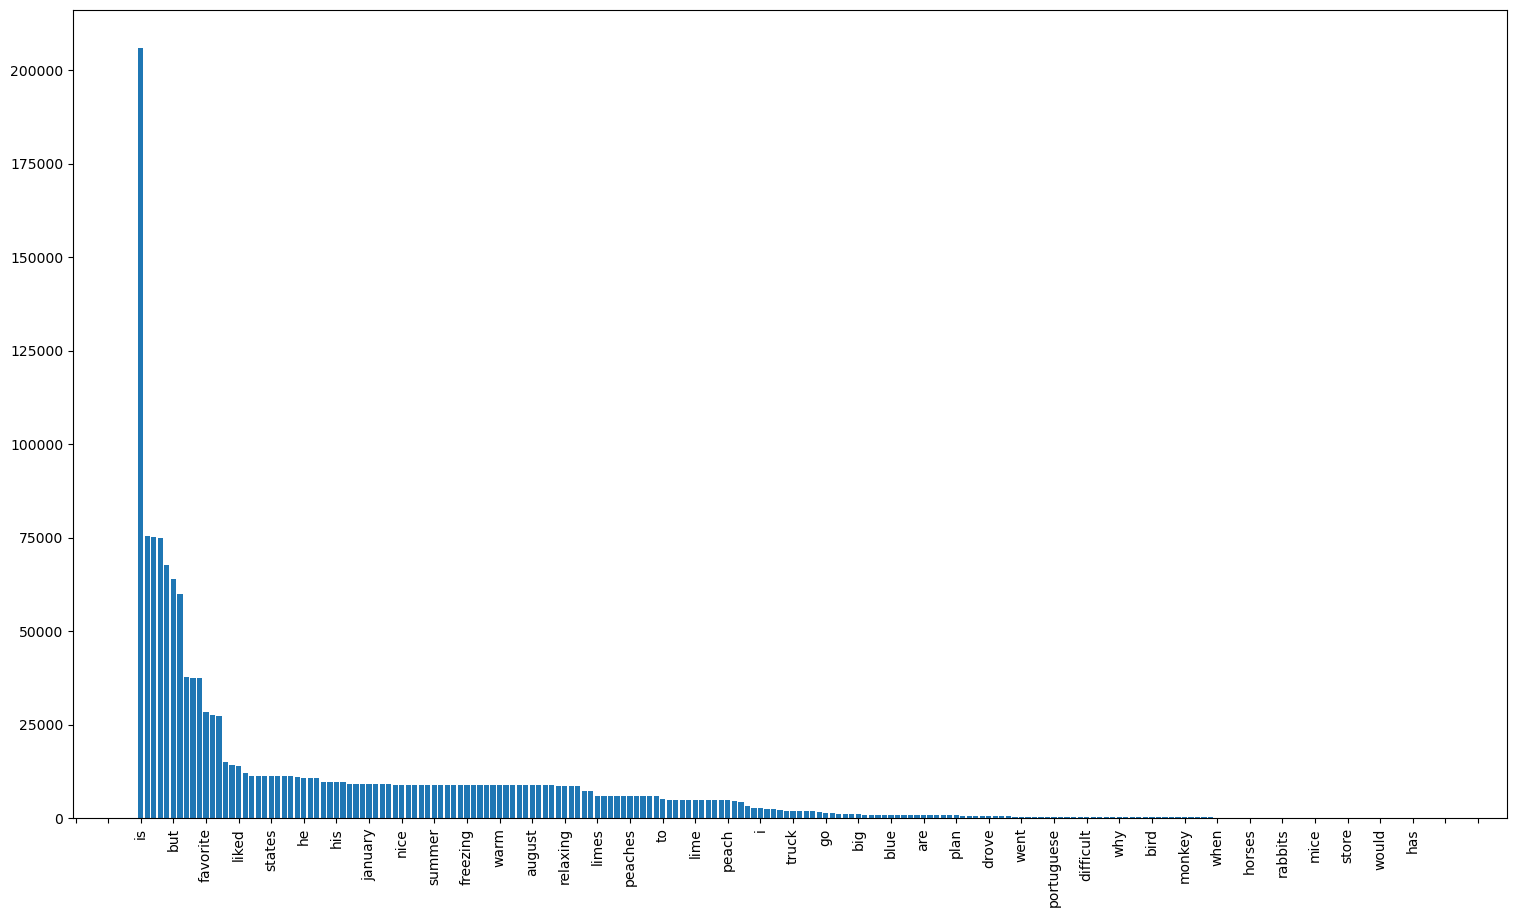

In [21]:
fig = plt.figure()
ax  = plt.gca()

ax.bar(x=english_words, height=english_counts)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.xticks(rotation=90)

fig.set_size_inches(18.5, 10.5)

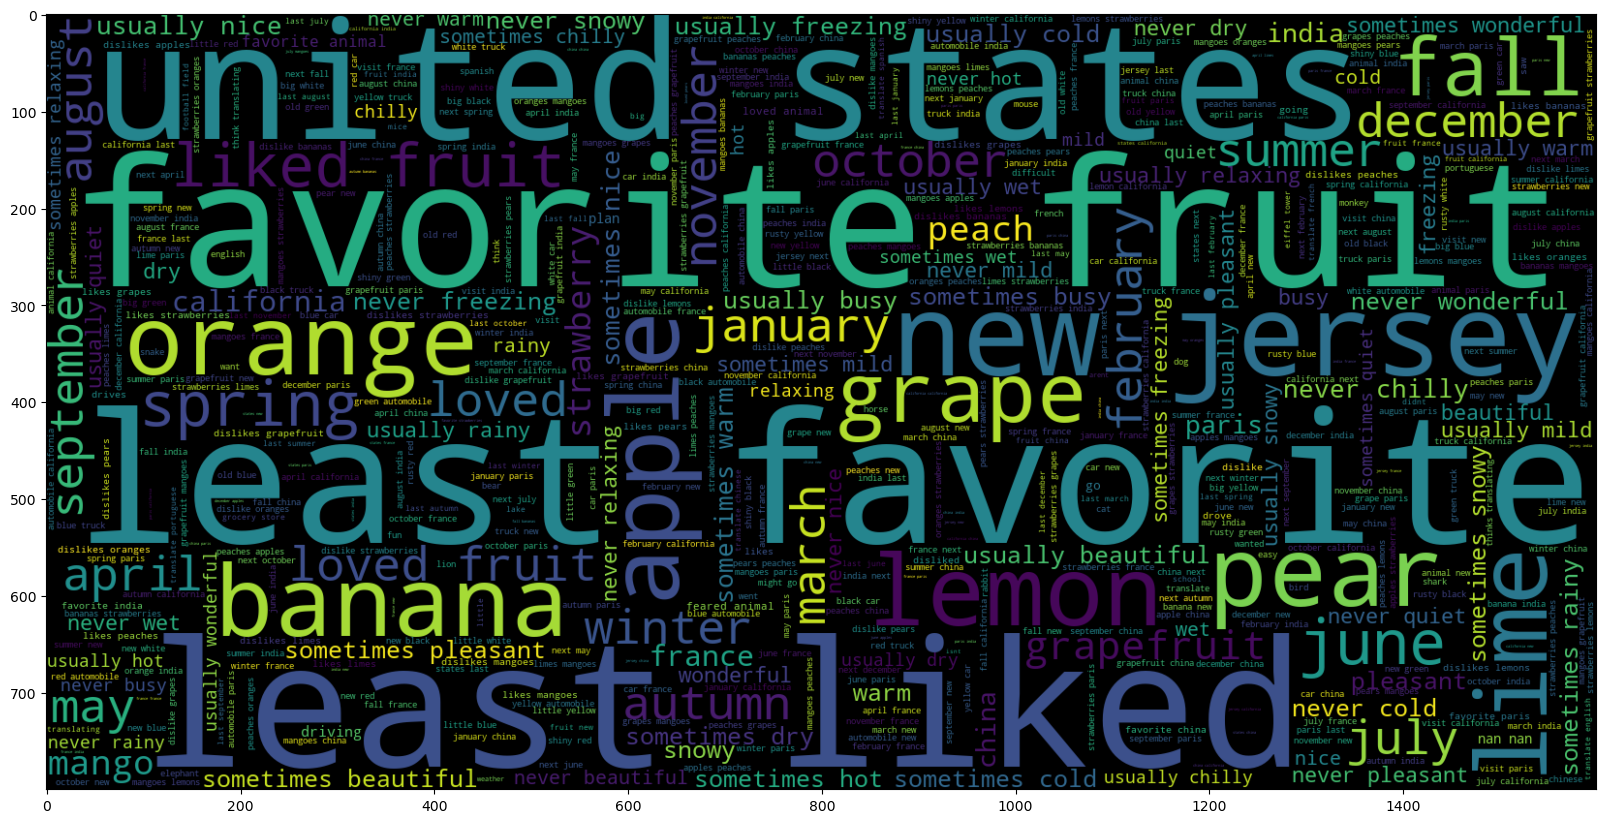

In [22]:
# Plot a word cloud

plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 2000, width = 1600, height = 800 ).generate(" ".join(df.english))
plt.imshow(wc, interpolation = 'bilinear')

In [23]:
import nltk
from nltk.tokenize import word_tokenize

print(word_tokenize("This is a test sentence."))

['This', 'is', 'a', 'test', 'sentence', '.']


In [24]:
# Maximum length (number of words) per document; needed for embeddings

maxlen_english = -1
for doc in df.english:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_english < len(tokens)):
        maxlen_english = len(tokens)
        
        
print("The maximum number of words in any document = ", maxlen_english)

The maximum number of words in any document =  15


In [25]:
# obtain the count of spanish words

words = []
for i in df['spanish']:
  for word in i.split():
    words.append(word)
words

['Go',
 'Ve',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '2877272',
 'CM',
 '4986655',
 'cueyayotl',
 'Go',
 'Vete',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '2877272',
 'CM',
 '4986656',
 'cueyayotl',
 'Go',
 'Vaya',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '2877272',
 'CM',
 '4986657',
 'cueyayotl',
 'Go',
 'Váyase',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '2877272',
 'CM',
 '6586271',
 'arh',
 'Hi',
 'Hola',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '538123',
 'CM',
 '431975',
 'Leono',
 'Hi',
 'Hola',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '538123',
 'CM',
 '10908352',
 'TeacherGeorge123',
 'Run',
 '¡Corre',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '906328',
 'papabear',
 '1685404',
 'Elenitigormiti',
 'Run',
 '¡Corran',
 'CCBY',
 '20',
 'France',
 'Attribution',
 'tatoebaorg',
 '906328',
 'papabear',
 '5213896',
 'cueyayotl',
 'Run',
 '¡Corra',
 'CCBY',
 '2

In [26]:
spanish_words_counts = Counter(words)
spanish_words_counts

Counter({'20': 139085,
         'France': 139058,
         'tatoebaorg': 139015,
         'CCBY': 139013,
         'Attribution': 139013,
         'CK': 92366,
         'Tom': 46506,
         'a': 41033,
         'marcelostockle': 35436,
         'I': 32216,
         'to': 30476,
         'Shishir': 29343,
         'de': 25602,
         'the': 25409,
         'que': 25291,
         'you': 22001,
         'la': 17283,
         'is': 14871,
         'no': 14381,
         'me': 13460,
         'en': 13442,
         'el': 13345,
         'es': 11982,
         'No': 11423,
         'un': 11068,
         'CM': 9932,
         'arh': 9844,
         'hayastan': 9653,
         'Mary': 9613,
         'in': 9475,
         'of': 9239,
         'that': 8601,
         'was': 7973,
         'se': 7553,
         'He': 7406,
         'una': 6945,
         'lo': 6749,
         'have': 6630,
         'The': 6623,
         'for': 6409,
         'it': 6203,
         'cueyayotl': 6196,
         'por': 5619,


In [27]:
# sort the dictionary by values
spanish_words_counts = sorted(spanish_words_counts.items(), key = operator.itemgetter(1), reverse = True)

spanish_words_counts

[('20', 139085),
 ('France', 139058),
 ('tatoebaorg', 139015),
 ('CCBY', 139013),
 ('Attribution', 139013),
 ('CK', 92366),
 ('Tom', 46506),
 ('a', 41033),
 ('marcelostockle', 35436),
 ('I', 32216),
 ('to', 30476),
 ('Shishir', 29343),
 ('de', 25602),
 ('the', 25409),
 ('que', 25291),
 ('you', 22001),
 ('la', 17283),
 ('is', 14871),
 ('no', 14381),
 ('me', 13460),
 ('en', 13442),
 ('el', 13345),
 ('es', 11982),
 ('No', 11423),
 ('un', 11068),
 ('CM', 9932),
 ('arh', 9844),
 ('hayastan', 9653),
 ('Mary', 9613),
 ('in', 9475),
 ('of', 9239),
 ('that', 8601),
 ('was', 7973),
 ('se', 7553),
 ('He', 7406),
 ('una', 6945),
 ('lo', 6749),
 ('have', 6630),
 ('The', 6623),
 ('for', 6409),
 ('it', 6203),
 ('cueyayotl', 6196),
 ('por', 5619),
 ('do', 5363),
 ('con', 5360),
 ('my', 5321),
 ('Im', 5133),
 ('está', 5011),
 ('Él', 4973),
 ('this', 4943),
 ('he', 4774),
 ('want', 4771),
 ('your', 4765),
 ('on', 4749),
 ('su', 4713),
 ('be', 4699),
 ('dont', 4683),
 ('Seael', 4672),
 ('with', 4632),
 (

In [28]:
spanish_words = []
spanish_counts = []

for i in range(len(spanish_words_counts)):
    spanish_words.append(spanish_words_counts[i][0])
    spanish_counts.append(spanish_words_counts[i][1])

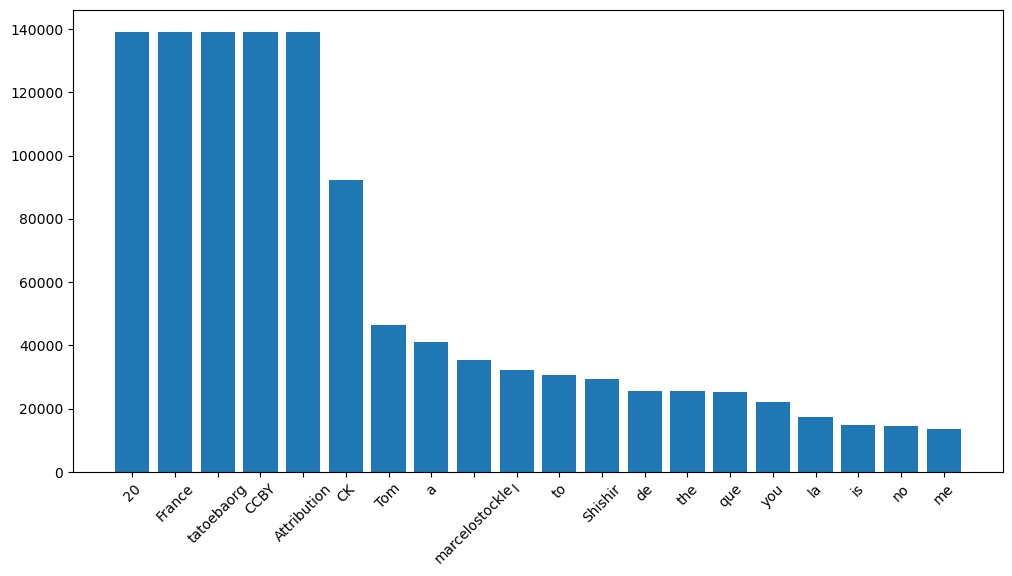

In [29]:
import matplotlib.pyplot as plt

# Sort by frequency (descending)
spanish_words_counts = sorted(spanish_words_counts, key=lambda x: x[1], reverse=True)

# Take top 20
top_n = 20
spanish_words = [word for word, count in spanish_words_counts[:top_n]]
spanish_counts = [count for word, count in spanish_words_counts[:top_n]]

# Plot
fig = plt.figure()
ax = plt.gca()

ax.bar(spanish_words, spanish_counts)

plt.xticks(rotation=45)
fig.set_size_inches(12, 6)

plt.show()

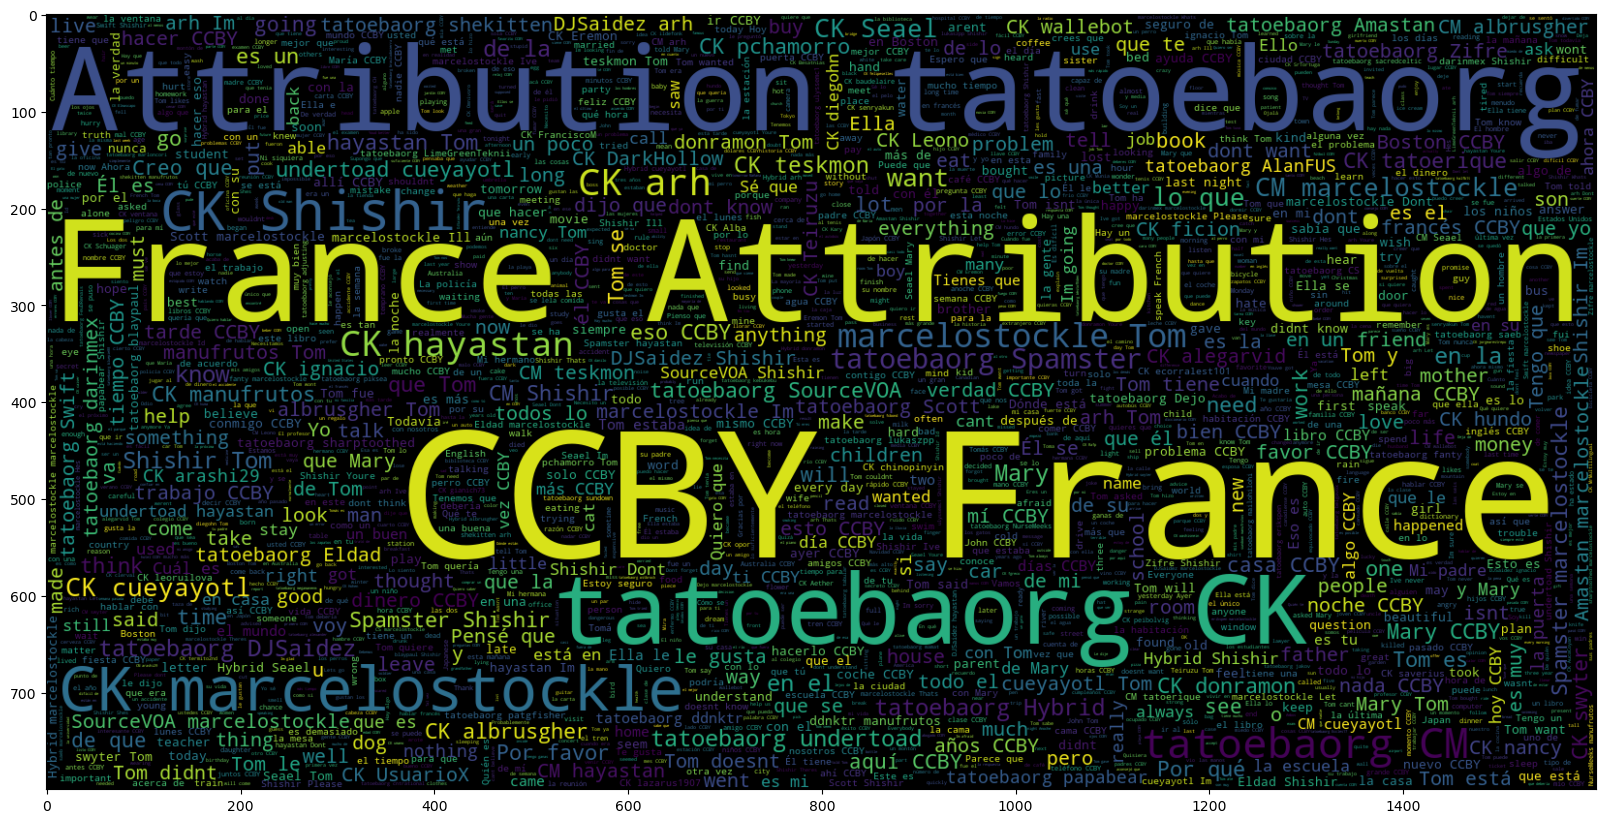

In [30]:
# plot the word cloud for spanish

plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 2000 , width = 1600 , height = 800).generate(" ".join(df.spanish))
plt.imshow(wc, interpolation = 'bilinear')

In [31]:
# Maximum length (number of words) per document; needed for embeddings

maxlen_spanish = -1
for doc in df.spanish:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_spanish < len(tokens)):
        maxlen_spanish = len(tokens)
        
print("The maximum number of words(spanish) in any document = ", maxlen_spanish)

The maximum number of words(spanish) in any document =  147


Pre-Process Data with help of Tokenization and Padding




In [32]:
def tokenize_and_pad(x, maxlen):
    
  # Tokenizer to tokenize the words and create sequences of tokenized words

  tokenizer = Tokenizer(char_level = False)
  tokenizer.fit_on_texts(x)

  sequences = tokenizer.texts_to_sequences(x)
  #  make allsequences same size
  padded = pad_sequences(sequences, maxlen = maxlen, padding = 'post')

  return tokenizer, sequences, padded

In [33]:
# Apply Tokenize and padding to the data 

x_tokenizer, x_sequences, x_padded = tokenize_and_pad(df.english, maxlen_english)
y_tokenizer, y_sequences, y_padded = tokenize_and_pad(df.spanish,  maxlen_spanish)

In [34]:
# Count total English words
total_english_words = len(english_words)

print("Total English Words:", total_english_words)

# Add special tokens (padding + start + end)
english_vocab_size = total_english_words + 3

print("Complete English Vocab Size:", english_vocab_size)

Total English Words: 200
Complete English Vocab Size: 203


In [35]:
# Total vocab size, since padding was added we add 1 to the total word count

spanish_vocab_size = total_spanish_words + 1
print("Complete Spanish Vocab Size:", spanish_vocab_size)

Complete Spanish Vocab Size: 297630


In [36]:
print("The tokenized version for document\n", df.english[-1:].item(),"\n is : ", x_padded[-1:])

The tokenized version for document
 nan 
 is :  [[109   0   0   0   0   0   0   0   0   0   0   0   0   0   0]]


In [37]:
print("The tokenized version for document\n", df.spanish[-1:].item(),"\n is : ", y_padded[-1:])

The tokenized version for document
 One day I woke up to find that God had put hair on my face I shaved it off The next day I found that God had put it back on my face so I shaved it off again On the third day when I found that God had put hair back on my face again I decided to let God have his way Thats why I have a beard	Un día me desperté y vi que Dios me había puesto pelo en la cara Me lo afeité Al día siguiente vi que Dios me lo había vuelto a poner en la cara así que me lo afeité otra vez Al tercer día cuando vi que Dios me había puesto pelo en la cara de nuevo decidí que Dios se saliera con la suya Por eso tengo barba	CCBY 20 France Attribution tatoebaorg 10104877 CK  10106093 manufrutos 
 is :  [[   131    214     10   2570    120     12    383     30   2240    116
     302    917     61     39   1001     10   7376     34    311     11
     420    214     10    525     30   2240    116    302     34    229
      61     39   1001    165     10   7376     34    311    331     61

In [38]:
# function to obtain the text from padded variables

def pad_to_text(padded, tokenizer):

    id_to_word = {id: word for word, id in tokenizer.word_index.items()}
    id_to_word[0] = ''

    return ' '.join([id_to_word[j] for j in padded])

In [39]:
pad_to_text(y_padded[0], y_tokenizer)

'go ve ccby 20 france attribution tatoebaorg 2877272 cm 4986655 cueyayotl                                                                                                                                        '

In [40]:
# Train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_padded, y_padded, test_size = 0.1)

Building and Traing the Model


In [41]:
maxlen_english = max([len(i.split()) for i in df['english']])
maxlen_spanish = max([len(i.split()) for i in df['spanish']])

print(maxlen_english)
print(maxlen_spanish)

15
147


In [42]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, RepeatVector, TimeDistributed, Dense

# Sequential Model
model = Sequential()

# embedding layer (input_length removed)
model.add(Embedding(input_dim=english_vocab_size, 
                    output_dim=256, 
                    mask_zero=True))

# encoder
model.add(LSTM(256))

# decoder
model.add(RepeatVector(maxlen_spanish))
model.add(LSTM(256, return_sequences=True))

model.add(TimeDistributed(Dense(spanish_vocab_size, activation='softmax')))

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# change the shape of target from 2D to 3D
y_train = np.expand_dims(y_train, axis = 2)
y_train.shape

(125111, 147, 1)

In [44]:
print(spanish_vocab_size)

297630


In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Vocabulary limit lagao
english_tokenizer = Tokenizer(num_words=15000)
english_tokenizer.fit_on_texts(df_english['english'])

spanish_tokenizer = Tokenizer(num_words=15000)
spanish_tokenizer.fit_on_texts(df_spanish['spanish'])

english_vocab_size = 15000
spanish_vocab_size = 15000

print("English vocab:", english_vocab_size)
print("Spanish vocab:", spanish_vocab_size)

English vocab: 15000
Spanish vocab: 15000


In [46]:
english_sequences = english_tokenizer.texts_to_sequences(df_english['english'])
spanish_sequences = spanish_tokenizer.texts_to_sequences(df_spanish['spanish'])

In [47]:
maxlen_english = 15
maxlen_spanish = 20   # limit kar diya

In [48]:
print(len(df_english))
print(len(df_spanish))

137860
139013


In [49]:
min_len = min(len(df_english), len(df_spanish))

df_english = df_english.iloc[:min_len]
df_spanish = df_spanish.iloc[:min_len]

print(len(df_english), len(df_spanish))

137860 137860


In [50]:
english_sequences = english_tokenizer.texts_to_sequences(df_english['english'])
spanish_sequences = spanish_tokenizer.texts_to_sequences(df_spanish['spanish'])

In [51]:
maxlen_spanish = y_train.shape[1]

In [52]:
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1], 1)

In [53]:
print(y_train.shape)

(125111, 147, 1)


In [54]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen_english = 15
maxlen_spanish = 20

x_train = pad_sequences(english_sequences, maxlen=maxlen_english, padding='post', truncating='post')
y_train = pad_sequences(spanish_sequences, maxlen=maxlen_spanish, padding='post', truncating='post')

print(x_train.shape)
print(y_train.shape)

(137860, 15)
(137860, 20)


In [55]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
import numpy as np

x_train = np.array(x_train)
y_train = np.array(y_train)

In [57]:
eng_vocab_size = int(x_train.max()) + 1
spanish_vocab_size = int(y_train.max()) + 1

print(eng_vocab_size)
print(spanish_vocab_size)

200
15000


In [58]:
from keras.models import Sequential
from keras.layers import Input, Embedding, LSTM, RepeatVector, TimeDistributed, Dense

model = Sequential()

# Input layer (IMPORTANT)
model.add(Input(shape=(15,)))

# Encoder
model.add(Embedding(input_dim=eng_vocab_size, output_dim=128))
model.add(LSTM(256))

# Decoder
model.add(RepeatVector(20))
model.add(LSTM(256, return_sequences=True))

# Output
model.add(TimeDistributed(Dense(spanish_vocab_size, activation='softmax')))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 15, 128)             │          25,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 256)                 │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_1 (RepeatVector)       │ (None, 20, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 20, 256)             │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 20, 15000)           │       3,855,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,800,152 (18.31 MB)

 Trainable params: 4,800,152 (18.31 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.fit(
    x_train,
    y_train,
    batch_size=16,
    epochs=5
)

Epoch 1/5
8617/8617 ━━━━━━━━━━━━━━━━━━━━ 3322s 384ms/step - accuracy: 0.1028 - loss: 5.2560
Epoch 2/5
8617/8617 ━━━━━━━━━━━━━━━━━━━━ 3166s 367ms/step - accuracy: 0.1065 - loss: 5.1506
Epoch 3/5
8617/8617 ━━━━━━━━━━━━━━━━━━━━ 3130s 363ms/step - accuracy: 0.1068 - loss: 5.1393
Epoch 4/5
8617/8617 ━━━━━━━━━━━━━━━━━━━━ 3065s 356ms/step - accuracy: 0.1070 - loss: 5.1341
Epoch 5/5
8617/8617 ━━━━━━━━━━━━━━━━━━━━ 3039s 353ms/step - accuracy: 0.1072 - loss: 5.1296


In [65]:
# save the model

model.save("my_model.keras")

Assess Model Performance

In [66]:
# function to make prediction

def prediction(x, x_tokenizer = x_tokenizer, y_tokenizer = y_tokenizer):
    
    predictions = model.predict(x)[0]
    id_to_word = {id: word for word, id in y_tokenizer.word_index.items()}
    id_to_word[0] = ''
    return ' '.join([id_to_word[j] for j in np.argmax(predictions,1)])

In [67]:
def pad_to_text(padded, tokenizer):
    
    id_to_word = {id: word for word, id in tokenizer.word_index.items()}
    id_to_word[0] = ''
    return ' '.join([id_to_word[j] for j in padded])

In [68]:
for i in range(5):

  print('Original English word - {}\n'.format(pad_to_text(x_test[i], x_tokenizer)))
  print('Original Spanish word - {}\n'.format(pad_to_text(y_test[i], y_tokenizer)))
  print('Predicted Spanish word - {}\n\n\n\n'.format(prediction(x_test[i:i+1])))

Original English word - the banana is your most loved fruit but the orange is his most loved 

Original Spanish word - start running empieza a correr ccby 20 france attribution tatoebaorg 2111521 ck 4557369 swyter                                                                                                                                     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Spanish word - shishir que de de de ccby ccby ccby ccby ccby ccby ccby 20 ck tatoebaorg tatoebaorg tom   




Original English word - the united states is chilly during winter but it is never nice in april 

Original Spanish word - they know how to make an atomic bomb saben cómo se construye una bomba atómica ccby 20 france attribution tatoebaorg 306465 cm 1288268 shishir                                                                                                                           

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Spanish word - shishir que de de de ccby ccby ccby ccby c